*Built with Grok Build*

# Homework Module 2 — Energy Calculation (591 track)

Course: **EEE591 / EEE419 Python for Rapid Engineering Solutions**.

Executable walkthrough of `hw2_591.py` (Problem 3).

For the damped sinusoid
$$
x(t,f) = e^{-t}\sin(2\pi f t),
$$
estimate the energy
$$
E(f) = \int_{0}^{T} |x(t,f)|^2\,dt
$$
with SciPy `quad` at several frequencies. A large but finite upper limit $T$ approximates
the improper integral over $[0,\infty)$ because of the exponential decay.


## Imports and signal model

Define $x(t,f)$ and the energy density $|x(t,f)|^2$.


In [1]:
import numpy as np
from scipy.integrate import quad

def x(t, f):
    """Damped sinusoid x(t) = exp(-t) * sin(2 π f t)."""
    return np.exp(-t) * np.sin(2 * np.pi * f * t)

def energy_integrand(t, f):
    """Instantaneous energy density |x(t, f)|^2."""
    return np.abs(x(t, f)) ** 2

# Quick sanity check at t=0
print("x(0, 10) =", x(0.0, 10.0))
print("|x(0, 10)|^2 =", energy_integrand(0.0, 10.0))


x(0, 10) = 0.0
|x(0, 10)|^2 = 0.0


## Frequencies and integration limits

Evaluate energy at $10\,\mathrm{Hz}$, $20\,\mathrm{Hz}$, and $1\,\mathrm{MHz}$.
Use $t \in [0, 30]$ so $e^{-t}$ has decayed by roughly $10^{-13}$; `quad`'s `limit`
parameter is raised for the highly oscillatory high-frequency case.


In [2]:
FREQUENCIES_LIST = [10, 20, 1e6]  # Hz
LOWER_LIMIT = 0
UPPER_LIMIT = 30  # finite proxy for infinity (exp decay)

print("Frequencies (Hz):", FREQUENCIES_LIST)
print(f"Integration interval: [{LOWER_LIMIT}, {UPPER_LIMIT}]")


Frequencies (Hz): [10, 20, 1000000.0]
Integration interval: [0, 30]


## Compute $E(f)$ with `quad` for each frequency

Pass the frequency through `args=(f,)` so `quad` only varies $t$.


In [3]:
energy_results = []
error_estimates = []

for f in FREQUENCIES_LIST:
    energy, energy_error = quad(
        energy_integrand,
        LOWER_LIMIT,
        UPPER_LIMIT,
        args=(f,),
        limit=100_000,  # more subdivisions for oscillatory integrands
    )
    energy_results.append(energy)
    error_estimates.append(energy_error)
    print(
        f"f = {f:g} Hz -> E = {energy:.12f},  "
        f"quad err est = {energy_error:.3e}"
    )


f = 10 Hz -> E = 0.249936690327,  quad err est = 1.409e-08
f = 20 Hz -> E = 0.249984169525,  quad err est = 1.348e-08


f = 1e+06 Hz -> E = 0.249999993209,  quad err est = 7.156e-09


## Graded-style report

Print energies to five decimal places for the three labeled frequencies.


In [4]:
answer_dict = {
    "10 Hz": energy_results[0],
    "20 Hz": energy_results[1],
    "1 MHz": energy_results[2],
}

for freq, energy in answer_dict.items():
    print(f"Energy at {freq}: {energy:.5f}")


Energy at 10 Hz: 0.24994
Energy at 20 Hz: 0.24998
Energy at 1 MHz: 0.25000


## Optional visualization

Plot $|x(t,f)|^2$ over a short window for the low-frequency cases to show decay and oscillation.


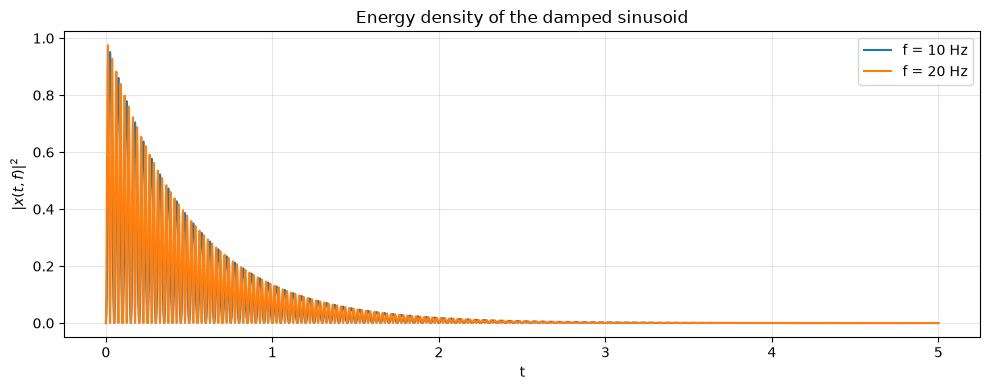

In [5]:
import matplotlib.pyplot as plt

t_plot = np.linspace(0, 5, 2000)
plt.figure(figsize=(10, 4))
for f in [10, 20]:
    plt.plot(t_plot, energy_integrand(t_plot, f), label=f"f = {f} Hz")
plt.xlabel("t")
plt.ylabel(r"$|x(t,f)|^2$")
plt.title("Energy density of the damped sinusoid")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## Takeaways

- Energy of a transient signal is an $L^2$ integral of the waveform.
- Exponential decay justifies truncating $[0,\infty)$ to a large finite $T$.
- Highly oscillatory integrands may need more `quad` subdivisions (`limit=...`).
- Original script: `hw2_591.py`.
